importing dataset

In [76]:
import pandas as pd
df=pd.read_csv("Loan.csv")
print(df.head(3))

    Loan_ID Gender Married Dependents Education Self_Employed  \
0  LP001002   Male      No          0  Graduate            No   
1  LP001003   Male     Yes          1  Graduate            No   
2  LP001005   Male     Yes          0  Graduate           Yes   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0         Urban           Y  


seeing all column names

In [77]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

printing specific column

In [78]:
df["LoanAmount"].head(5)

0      NaN
1    128.0
2     66.0
3    120.0
4    141.0
Name: LoanAmount, dtype: float64

In [79]:
df["Credit_History"].tail(5)

609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Credit_History, dtype: float64

shape,describe,info

In [80]:
df.shape


(614, 13)

In [81]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [82]:
df.info

<bound method DataFrame.info of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849          

datatypes

In [83]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

replacing column names


In [84]:
df.rename(columns={
    "Gender":"Sex"
})

,Loan_ID,Sex,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


group by

In [85]:
df.groupby("Gender")["LoanAmount"].mean()

Gender
Female    126.697248
Male      149.265957
Name: LoanAmount, dtype: float64

aggregate function

In [86]:
df["LoanAmount"].mean()

np.float64(146.41216216216216)

In [87]:
df["LoanAmount"].mode()

0    120.0
Name: LoanAmount, dtype: float64

In [88]:
df["LoanAmount"].median()

np.float64(128.0)

In [89]:
df["LoanAmount"].std()

np.float64(85.58732523570545)

In [90]:
df["LoanAmount"].var()

np.float64(7325.190241002422)

checking empty or null values

In [91]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [92]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
609    False
610    False
611    False
612    False
613    False
Length: 614, dtype: bool

fixing null values

In [93]:
df['Gender'] = df['Gender'].fillna("Male")

In [94]:
df['Married'] = df['Married'].fillna("Yes")

In [95]:
df['Dependents'] = df['Dependents'].fillna(0)

In [96]:
df['Self_Employed'] = df['Self_Employed'].fillna("Yes")
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History'] = df['Credit_History'].fillna(1.0)

after fixing null values

In [97]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

correlation

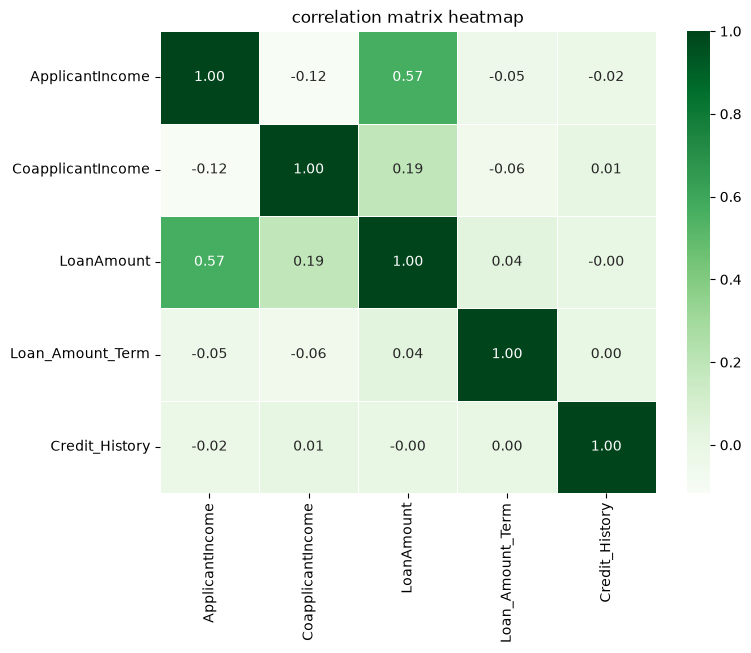

In [98]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5
)
plt.title("correlation matrix heatmap")
plt.show()


In [99]:
df.corr(numeric_only=True)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565620,-0.045242,-0.018615
CoapplicantIncome,-0.116605,1.000000,0.187828,-0.059675,0.011134
LoanAmount,0.565620,0.187828,1.000000,0.038801,-0.001431
Loan_Amount_Term,-0.045242,-0.059675,0.038801,1.000000,0.000432
Credit_History,-0.018615,0.011134,-0.001431,0.000432,1.000000


outlier

In [100]:
q1=df['ApplicantIncome'].quantile(0.25)
q3=df["ApplicantIncome"].quantile(0.75)
IQR=q3-q1
lower_limit=q1-1.5*IQR
upper_limit=q3+1.5*IQR
print("q1:",q1)
print('q3:',q3)
print("IQR:",IQR)
print("lower_limit:",lower_limit)
print("upper_limit:",upper_limit)
outliers=df[
    (df["ApplicantIncome"]<lower_limit) |
    (df["ApplicantIncome"]>upper_limit)
]
print("\n ApplicantIncome Outliers:",len(outliers))
print("\n ApplicantIncome outliers:")
print(outliers[["Loan_ID","ApplicantIncome"]].head(20))

q1: 2877.5
q3: 5795.0
IQR: 2917.5
lower_limit: -1498.75
upper_limit: 10171.25

 ApplicantIncome Outliers: 50

 ApplicantIncome outliers:
      Loan_ID  ApplicantIncome
9    LP001020            12841
34   LP001100            12500
54   LP001186            11500
67   LP001233            10750
102  LP001350            13650
106  LP001369            11417
115  LP001401            14583
119  LP001422            10408
126  LP001448            23803
128  LP001451            10513
130  LP001469            20166
138  LP001492            14999
144  LP001508            11757
146  LP001516            14866
155  LP001536            39999
171  LP001585            51763
183  LP001637            33846
185  LP001640            39147
191  LP001656            12000
199  LP001673            11000


TypeError: 'str' object is not callable

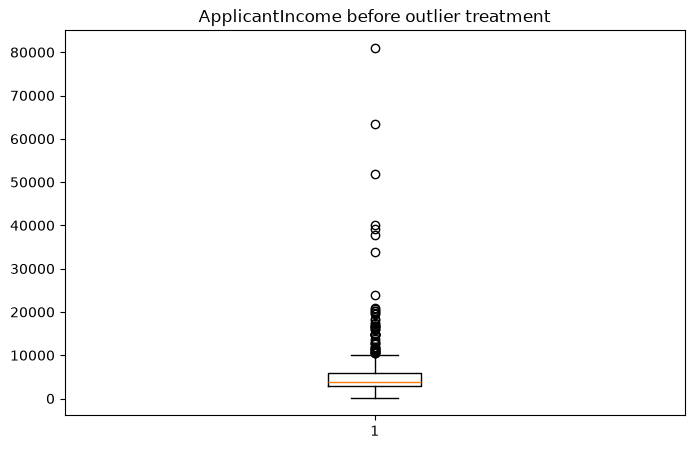

In [101]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df['ApplicantIncome'])
plt.title("ApplicantIncome before outlier treatment")
plt.ylabel("ApplicantIncome")
plt.show()

fixing outlier

In [ ]:
df["ApplicantIncome_capped"]=df["ApplicantIncome"].clip(
    lower=lower_limit,
    upper=upper_limit
)

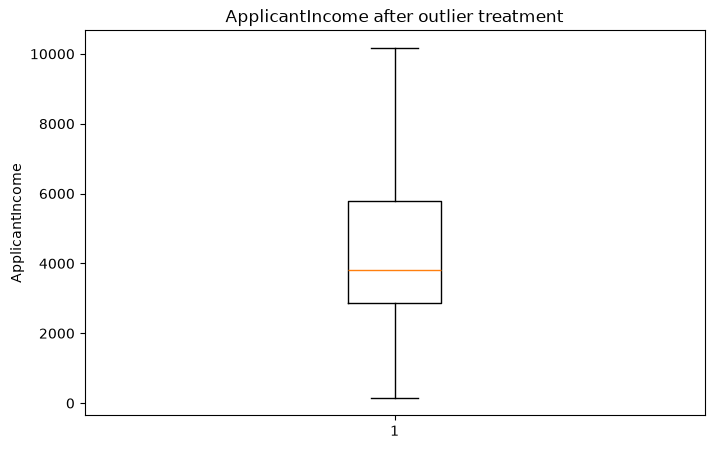

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df['ApplicantIncome_capped'])
plt.title("ApplicantIncome after outlier treatment")
plt.ylabel("ApplicantIncome")
plt.show()

sort values

In [ ]:
df.sort_values("LoanAmount")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_capped
568,LP002840,Female,No,0,Graduate,No,2378,0.0,9.0,360.0,1.0,Urban,N,2378.00
14,LP001030,Male,Yes,2,Graduate,No,1299,1086.0,17.0,120.0,1.0,Urban,Y,1299.00
133,LP001482,Male,Yes,0,Graduate,Yes,3459,0.0,25.0,120.0,1.0,Semiurban,Y,3459.00
94,LP001325,Male,No,0,Not Graduate,No,3620,0.0,25.0,120.0,1.0,Semiurban,Y,3620.00
555,LP002792,Male,Yes,1,Graduate,No,5468,1032.0,26.0,360.0,1.0,Semiurban,Y,5468.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,LP002191,Male,Yes,0,Graduate,No,19730,5266.0,570.0,360.0,1.0,Rural,N,10171.25
155,LP001536,Male,Yes,3+,Graduate,No,39999,0.0,600.0,180.0,0.0,Semiurban,Y,10171.25
561,LP002813,Female,Yes,1,Graduate,Yes,19484,0.0,600.0,360.0,1.0,Semiurban,Y,10171.25
130,LP001469,Male,No,0,Graduate,Yes,20166,0.0,650.0,480.0,1.0,Urban,Y,10171.25


In [ ]:
df.sort_values("Loan_Amount_Term",ascending=False)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_capped
248,LP001824,Male,Yes,1,Graduate,No,2882,1843.0,123.0,480.0,1.0,Semiurban,Y,2882.00
75,LP001255,Male,No,0,Graduate,No,3750,0.0,113.0,480.0,1.0,Urban,N,3750.00
573,LP002862,Male,Yes,2,Not Graduate,No,6125,1625.0,187.0,480.0,1.0,Semiurban,N,6125.00
130,LP001469,Male,No,0,Graduate,Yes,20166,0.0,650.0,480.0,1.0,Urban,Y,10171.25
168,LP001579,Male,No,0,Graduate,No,2237,0.0,63.0,480.0,0.0,Semiurban,N,2237.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,LP001806,Male,No,0,Graduate,No,2965,5701.0,155.0,60.0,1.0,Urban,Y,2965.00
68,LP001238,Male,Yes,3+,Not Graduate,Yes,7100,0.0,125.0,60.0,1.0,Urban,Y,7100.00
262,LP001870,Female,No,1,Graduate,No,3481,0.0,155.0,36.0,1.0,Semiurban,N,3481.00
546,LP002768,Male,No,0,Not Graduate,No,3358,0.0,80.0,36.0,1.0,Semiurban,N,3358.00


conditions

In [ ]:
highest_amount=df[df["LoanAmount"]>150]
print(highest_amount.head(5))

     Loan_ID Gender Married Dependents Education Self_Employed  \
5   LP001011   Male     Yes          2  Graduate           Yes   
7   LP001014   Male     Yes         3+  Graduate            No   
8   LP001018   Male     Yes          2  Graduate            No   
9   LP001020   Male     Yes          1  Graduate            No   
12  LP001028   Male     Yes          2  Graduate            No   

    ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
5              5417             4196.0       267.0             360.0   
7              3036             2504.0       158.0             360.0   
8              4006             1526.0       168.0             360.0   
9             12841            10968.0       349.0             360.0   
12             3073             8106.0       200.0             360.0   

    Credit_History Property_Area Loan_Status  ApplicantIncome_capped  
5              1.0         Urban           Y                 5417.00  
7              0.0     Semiu

And &

In [ ]:
filtered=df[(df["LoanAmount"]>200)&(df["Loan_Amount_Term"]<360)]
print(filtered.head(5))

      Loan_ID Gender Married Dependents     Education Self_Employed  \
155  LP001536   Male     Yes         3+      Graduate            No   
171  LP001585   Male     Yes         3+      Graduate            No   
253  LP001843   Male     Yes          1  Not Graduate            No   
333  LP002101   Male     Yes          0      Graduate           Yes   
372  LP002201   Male     Yes          2      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
155            39999                0.0       600.0             180.0   
171            51763                0.0       700.0             300.0   
253             2661             7101.0       279.0             180.0   
333            63337                0.0       490.0             180.0   
372             9323             7873.0       380.0             300.0   

     Credit_History Property_Area Loan_Status  ApplicantIncome_capped  
155             0.0     Semiurban           Y                1

In [ ]:
filtered=df[(df["LoanAmount"]>200)  | (df["Loan_Amount_Term"]<360)]
print(filtered.head(5))

     Loan_ID Gender Married Dependents     Education Self_Employed  \
5   LP001011   Male     Yes          2      Graduate           Yes   
9   LP001020   Male     Yes          1      Graduate            No   
14  LP001030   Male     Yes          2      Graduate            No   
16  LP001034   Male      No          1  Not Graduate            No   
19  LP001041   Male     Yes          0      Graduate           Yes   

    ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
5              5417             4196.0       267.0             360.0   
9             12841            10968.0       349.0             360.0   
14             1299             1086.0        17.0             120.0   
16             3596                0.0       100.0             240.0   
19             2600             3500.0       115.0             342.0   

    Credit_History Property_Area Loan_Status  ApplicantIncome_capped  
5              1.0         Urban           Y                 5417.00  
9   

visualization


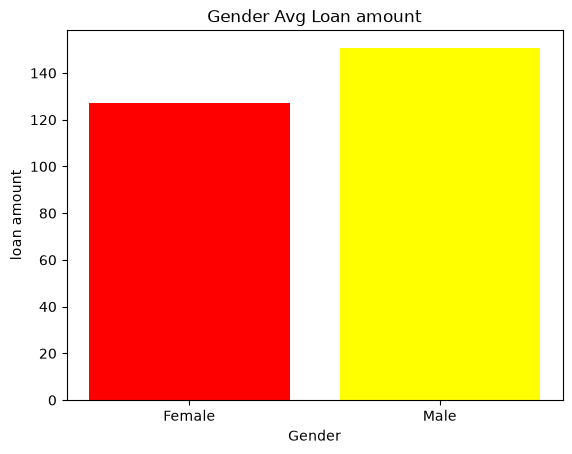

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
gender=df.groupby("Gender")["LoanAmount"].mean()
plt.bar(gender.index,
        gender.values,
        color=["red","yellow"]
        )
plt.title("Gender Avg Loan amount")
plt.xlabel("Gender")
plt.ylabel("loan amount")
plt.show()

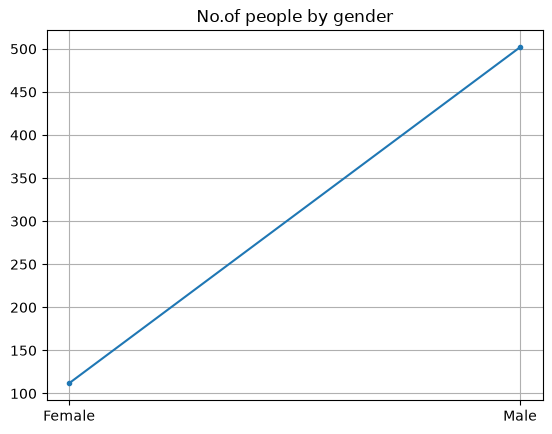

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
gender=df.groupby("Gender")["LoanAmount"].count()
plt.Figure(figsize=(8,5))
plt.plot(gender.index,
        gender.values,
        marker=".")
plt.title("No.of people by gender")
plt.xlabel=("Gender")
plt.ylabel=("loan amount")
plt.grid(True)
plt.show()

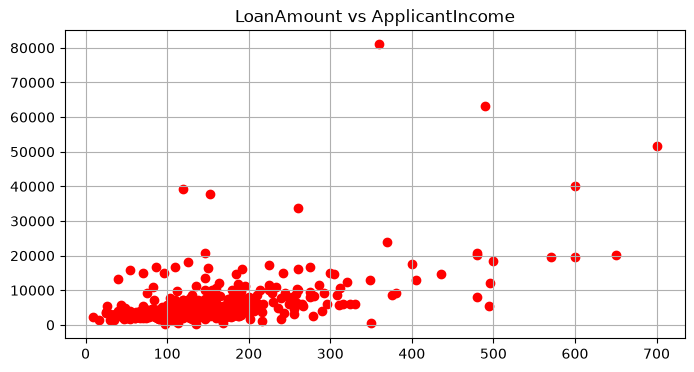

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(df["LoanAmount"], df["ApplicantIncome"], color="red")

plt.title("LoanAmount vs ApplicantIncome")
plt.xlabel = ("LoanAmount")
plt.ylabel = ("ApplicantIncome")
plt.grid(True)

plt.show()


LoanAmount Statistics After Treatment:
count    614.000000
mean     146.412162
std       84.037468
min        9.000000
25%      100.250000
50%      129.000000
75%      164.750000
max      700.000000
Name: LoanAmount, dtype: float64


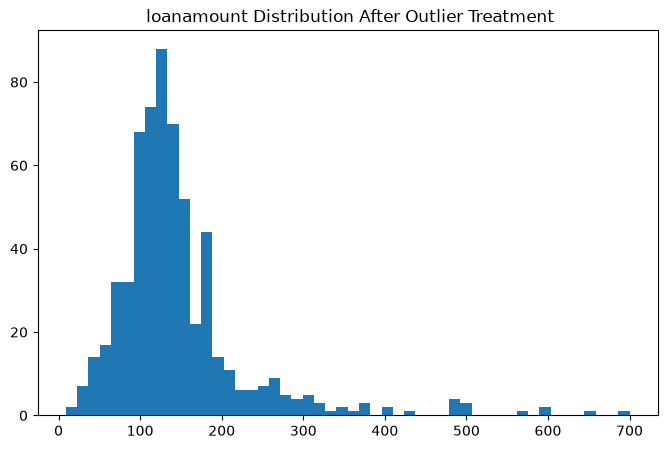

In [ ]:
print("\nLoanAmount Statistics After Treatment:")
print(df["LoanAmount"].describe())

plt.figure(figsize=(8, 5))

plt.hist(
    df["LoanAmount"],
    bins=50
)

plt.title(" loanamount Distribution After Outlier Treatment")
plt.xlabel = ("LoanAmount")
plt.ylabel = ("Frequency")

plt.show()

First 5 Rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0  146.412162             360.0   
1             4583             1508.0  128.000000             360.0   
2             3000                0.0   66.000000             360.0   
3             2583             2358.0  120.000000             360.0   
4             6000                0.0  141.000000             360.0   

   Credit_History Property_Area Loan_Status  ApplicantIncome_capped  
0             1.0         Urban           Y                  5849.0  
1   

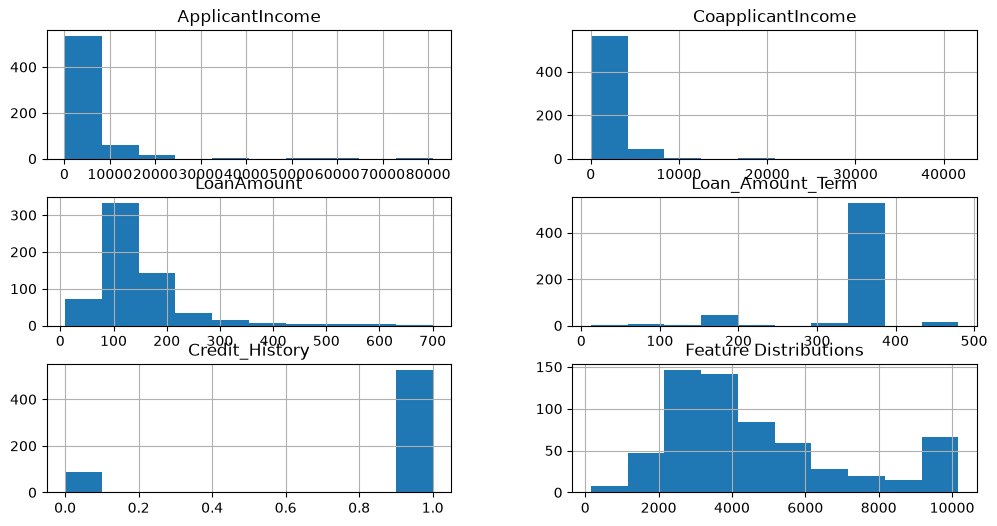

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("First 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nShape of Dataset:")
print(df.shape)
df.hist(figsize=(12,6))
plt.title("Feature Distributions")
plt.show()

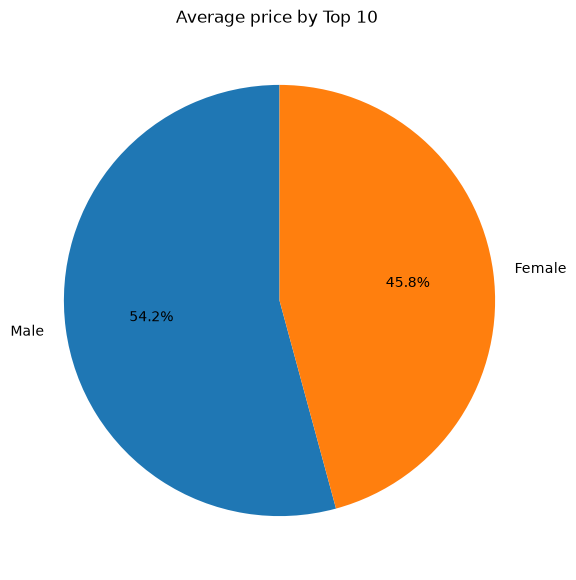

In [ ]:
import matplotlib.pyplot as plt
avg_amount = df.groupby("Gender")['LoanAmount'].mean().sort_values(ascending=False)
top_amount = avg_amount.head(10)

plt.figure(figsize=(7,7))
plt.pie(top_amount.values,
        labels=top_amount.index.astype(str),
        autopct="%1.1f%%",
        startangle=90)

plt.title("Average price by Top 10 ")
plt.show()

Train & Test


In [ ]:
df.to_csv("preprocessed_data_1.csv",index=False)
print("saved")

saved


installing sklearn

In [ ]:
! pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
df=pd.read_csv("preprocessed_data_1.csv")
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_capped
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,4583.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,2583.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0


In [ ]:
x = df.drop("LoanAmount",axis=1)
y = df["LoanAmount"]
x = pd.get_dummies(x,drop_first=True)
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features: ",x_train.shape)
print("Testing Features: ",x_test.shape)

print("Training Target: ",y_train.shape)
print("Training Target: ",y_test.shape)
print("Training data")
print(x_train.head())

print("\nTesting data")
print(x_test.head())

Training Features:  (491, 628)
Testing Features:  (123, 628)
Training Target:  (491,)
Training Target:  (123,)
Training data
     ApplicantIncome  CoapplicantIncome  Loan_Amount_Term  Credit_History  \
83              6000             2250.0             360.0             1.0   
90              2958             2900.0             360.0             1.0   
227             6250             1695.0             360.0             1.0   
482             2083             3150.0             360.0             1.0   
464             4166                0.0             360.0             0.0   

     ApplicantIncome_capped  Loan_ID_LP001003  Loan_ID_LP001005  \
83                   6000.0             False             False   
90                   2958.0             False             False   
227                  6250.0             False             False   
482                  2083.0             False             False   
464                  4166.0             False             False   

     Loan

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'ApplicantIncome_capped'],
      dtype='str')

In [111]:
df["ApplicantIncome"]

0      5849
1      4583
2      3000
3      2583
4      6000
       ... 
609    2900
610    4106
611    8072
612    7583
613    4583
Name: ApplicantIncome, Length: 614, dtype: int64

In [ ]:
df['LoanAmount']

0      146.412162
1      128.000000
2       66.000000
3      120.000000
4      141.000000
          ...    
609     71.000000
610     40.000000
611    253.000000
612    187.000000
613    133.000000
Name: LoanAmount, Length: 614, dtype: float64

In [110]:
import numpy as np
X = df['ApplicantIncome']
Y = df['LoanAmount']
m = ((X - X.mean())*(Y - Y.mean()))/((X - X.mean())**2).sum()
c=Y.mean() - m*X.mean()
Y_pred = m*X+c
print(Y_pred)
Y_pred = np.round(Y_pred).astype(int)
print(Y_pred.head())
print("Slope: ",m)
print("Intercept: ",c)

0      146.412162
1      146.411620
2      146.391858
3      146.402978
4      146.412078
          ...    
609    146.391503
610    146.404332
611    146.445340
612    146.420590
613    146.411768
Length: 614, dtype: float64
0    146
1    146
2    146
3    146
4    146
dtype: int64
Slope:  0      0.000000e+00
1      6.603211e-07
2      8.447960e-06
3      3.256245e-06
4     -1.411251e-07
           ...     
609    8.252305e-06
610    6.035015e-06
611    1.243297e-05
612    3.866823e-06
613    4.810045e-07
Length: 614, dtype: float64
Intercept:  0      146.412162
1      146.408594
2      146.366514
3      146.394567
4      146.412925
          ...    
609    146.367571
610    146.379552
611    146.344981
612    146.391268
613    146.409563
Length: 614, dtype: float64


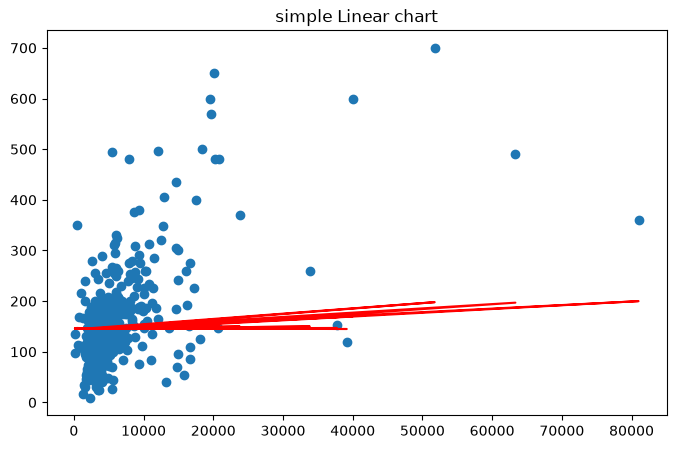

In [114]:
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.plot(X,Y_pred,color = "red")
plt.title("simple Linear chart")
plt.xlabel=("Applicant Income")
plt.ylabel=("Loan Amount")
plt.show()

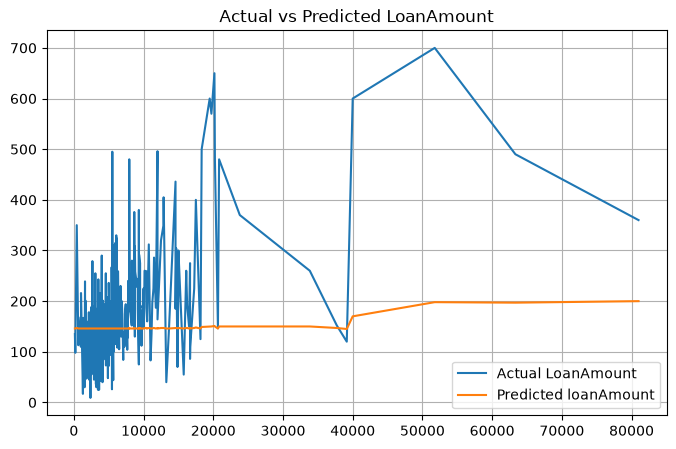

In [115]:
import matplotlib.pyplot as plt
sorted_data = pd.DataFrame({
    "X":X,
    "Actual" : Y,
    "Predicted":Y_pred
}).sort_values("X")
plt.figure(figsize=(8,5))
plt.plot(sorted_data["X"],sorted_data["Actual"],label="Actual LoanAmount")
plt.plot(sorted_data["X"],sorted_data["Predicted"],label="Predicted loanAmount")
plt.title("Actual vs Predicted LoanAmount")
plt.xlabel=("Applicant Income")
plt.ylabel=("Loan Amount")
plt.legend()
plt.grid(True)
plt.show()